In [1]:

import os
from pathlib import Path
from acados_template import AcadosOcp
from commom_utils.ode_system import ODESystem, check_system_ok, MHESyntheticDataGenerator
import numpy as np
import matplotlib.pyplot as plt

from gauss_newton.gauss_newton_math import SystemJacobian

from commom_utils.systems import *
from mhe.mhe_base_model_interface import MheModel, MheCogeGenerator
from mhe.params import MheParams
from mhe.mhe_utils import MheEstimationData, run_mhe_estimation, plot_mhe_results

In [2]:
mhe_horizont = 400
ts = 0.02


if(0):
    measurements_residual_r = np.diag([1, 1])                 # R: 1x1
    state_prior_q0 = np.diag([1, 1])                          # Q0: 1x1
    noise_peanlty_w = np.eye(2) * 1e3                    # Q: 1x1
    fim_scaler = 0.2

    mhe_params = MheParams(
            dt=ts,
            mhe_horizont=mhe_horizont,
            state_prior_q0=state_prior_q0,
            noise_peanlty_w=noise_peanlty_w,
            measurements_residual_r=measurements_residual_r,
            bounds_noise = 2*[np.array([-0.01, 0.01])],
            bounds_state = 2*[np.array([-np.inf, np.inf])],
            bounds_param = 2*[np.array([-2000, 2000])],
            fim_scaler=fim_scaler
        )

    mhe_params.print()

    system =  MassSpringDamper()
    c0 = np.array([1.0, 10.0]) 
    theta_true = np.array([3, 1.0])
  
elif(1):
    measurements_residual_r = np.diag([1])                 # R: 1x1
    state_prior_q0 = np.diag([1])                          # Q0: 1x1
    noise_peanlty_w = np.eye(1) * 1e3                    # Q: 1x1
    fim_scaler = 0.2
    wheel_base = 2.65

    mhe_params = MheParams(
            dt=ts,
            mhe_horizont=mhe_horizont,
            state_prior_q0=state_prior_q0,
            noise_peanlty_w=noise_peanlty_w,
            measurements_residual_r= measurements_residual_r,
            bounds_noise = [[-0.01, 0.01]],
            bounds_state = [[-np.inf, np.inf]],
            bounds_param = [np.deg2rad([-5, 5]), [-1, 1]],
            fim_scaler=fim_scaler
        )

    mhe_params.print()

    system =  KinematicBycicle(wheelbase = 2.65)
    c0 = np.array([0]) 
    theta_true = np.array([0.05, np.deg2rad(-0.3)])

elif(1):
    measurements_residual_r = np.diag([1])                 # R: 1x1
    state_prior_q0 = np.diag([1, 1])                           # Q0: 1x1
    noise_peanlty_w = np.eye(2) * 1e3                    # Q: 1x1
    fim_scaler = 0.2

    mhe_params = MheParams(
            dt=ts,
            mhe_horizont=mhe_horizont,
            state_prior_q0=state_prior_q0,
            noise_peanlty_w=noise_peanlty_w,
            measurements_residual_r=measurements_residual_r,
            bounds_noise = 2*[[-0.01, 0.01]],
            bounds_state = 2*[[-1e5, 1e5]],
            bounds_param = [[0, 20]],
            fim_scaler=fim_scaler
        )

    mhe_params.print()

    system =  Integrator()
    c0 =  np.array([0.0, 0.0])
    theta_true = np.array([1.0])

class MyCogeGenerator(MheCogeGenerator):
    def __init__(self):
        super().__init__(system, mhe_params,  Path(os.getcwd())/'mhe/tmp_generated', 'kinematik_mhe')

    def modify_ocp_problem(self, ocp_mhe: AcadosOcp) -> AcadosOcp:
        ocp_mhe.solver_options.print_level = 2
        ocp_mhe.solver_options.nlp_solver_stats_level = 2
        ocp_mhe.solver_options.nlp_solver_max_iter = 150
        return ocp_mhe

generator = MyCogeGenerator()

assert check_system_ok(system) == True



INFO:2026-04-09 16:05:02,742:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-04-09 16:05:02,742 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


dt: 0.02
mhe_horizont: 400
state_prior_q0: [[1]]
noise_peanlty_w: [[1000.]]
measurements_residual_r: [[1]]
bounds_param: [array([-0.08726646,  0.08726646]), [-1, 1]]
bounds_state: [[-inf, inf]]
bounds_noise: [[-0.01, 0.01]]
fim_scaler: 0.2


In [3]:
acados_solver_mhe = generator.generate_code()

Please export ACADOS_SOURCE_DIR to avoid this warning.
[-0.08726646 -1.        ]
[0.08726646 1.        ]
[1 2]
kinematik_mhe
2 1
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this warning.
Please export ACADOS_SOURCE_DIR to avoid this 

In [8]:
# Create the generator

simulation_system = KinematicBycicleActuator(wheelbase=2.65, kp = 200, kv = 10)
c0 = np.array(3*[0]) 

data_gen = MHESyntheticDataGenerator(simulation_system, sigma=0.0)

# Parameters
t0 = 0
T_f = mhe_params.dt * mhe_params.mhe_horizont          
N_measurement = mhe_params.mhe_horizont               
overlap_points = int(N_measurement*0.5)
num_windows = 20                                    # number of overlapping windows


# Generate exact windows
t_windows, u_windows, meas_windows, full_windows = data_gen.generate_sliding_windows_exact(
    c0, theta_true, t0, T_f, num_windows, N_measurement, overlap_points=overlap_points
)

# Check the time span of the first window
print(f"Window 0: start={t_windows[0][0]:.6f}, end={t_windows[0][-1]:.6f}, span={t_windows[0][-1]-t_windows[0][0]:.6f}")
# This should equal T_f
def get_window(i):
    return t_windows[i], u_windows[i], meas_windows[i]

Window 0: start=0.000000, end=8.000000, span=8.000000


/tmp/ipykernel_321589/2631265758.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


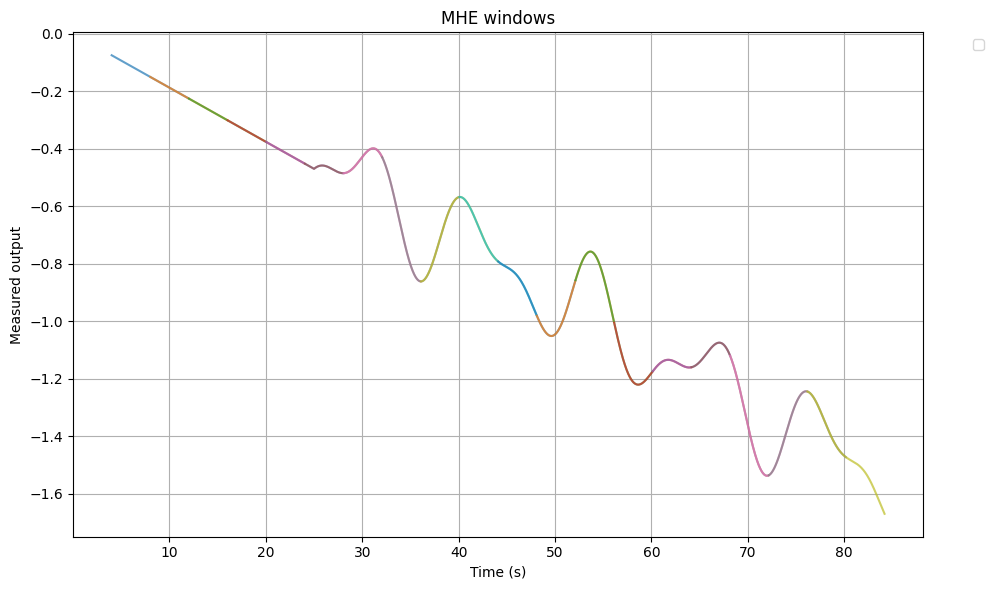

In [9]:
plt.figure(figsize=(10, 6))
for i in range(1, 20):
    t, simU, simY = get_window(i)
    plt.plot(t, simY[:, :3], alpha=0.7)

plt.xlabel('Time (s)')
plt.ylabel('Measured output')
plt.title('MHE windows')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
initial_theta = theta_true


results = run_mhe_estimation(
    mhe_model=generator.get_model(),
    acados_solver_factory= acados_solver_mhe,   # you might pass a pre‑created solver or a factory
    get_window_func=get_window,
    overlap_points=overlap_points,
    initial_theta = initial_theta,
    mhe_params=mhe_params,
    num_windows=num_windows,
    R_inv=mhe_params.measurements_residual_r,
    forgetting_factor = 0.01,
    compute_advanced_fim = True,
    plot=0   # set to True if you want live plots
)

MHE windows:   5%|▌         | 1/20 [00:00<00:03,  4.92window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   6.2770e-02   1.2884e-03   0.0000e+00   1.5043e-07         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   3.5929e-10   3.4888e-12   0.0000e+00   9.6804e-08         0         3   1.57e+00   0.00e+00  1.00e+00    
Optimal solution found! Converged to KKT point.


MHE windows:  10%|█         | 2/20 [00:00<00:03,  4.93window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   1.2784e-01   3.4888e-12   0.0000e+00   9.6804e-08         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   1.5774e-10   1.3033e-12   0.0000e+00   2.2897e-07         0         4   7.63e-02   0.00e+00  1.00e+00    
Optimal solution found! Converged to KKT point.


MHE windows:  15%|█▌        | 3/20 [00:00<00:03,  4.81window/s]

...

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   4.3433e-02   5.3368e-03   0.0000e+00   1.1134e-07         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   6.5490e-10   6.6189e-12   0.0000e+00   5.3326e-08         0         5   4.45e-01   0.00e+00  1.00e+00    
Optimal solution found! Converged to KKT point.


MHE windows:  95%|█████████▌| 19/20 [00:05<00:00,  3.29window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   2.3434e-02   5.3405e-03   0.0000e+00   5.3326e-08         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   4.1259e-10   6.0867e-12   0.0000e+00   3.1687e-08         0         5   4.16e-01   0.00e+00  1.00e+00    
Optimal solution found! Converged to KKT point.


MHE windows: 100%|██████████| 20/20 [00:05<00:00,  3.58window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   3.1888e-02   3.9377e-03   0.0000e+00   3.1687e-08         0         0   0.00e+00   0.00e+00  1.00e+00    
     1   3.4448e-10   4.6068e-12   0.0000e+00   1.2516e-07         0         4   2.91e-01   0.00e+00  1.00e+00    
Optimal solution found! Converged to KKT point.


In [14]:
results[0].param_est

array([ 0.04215575, -0.00510498])

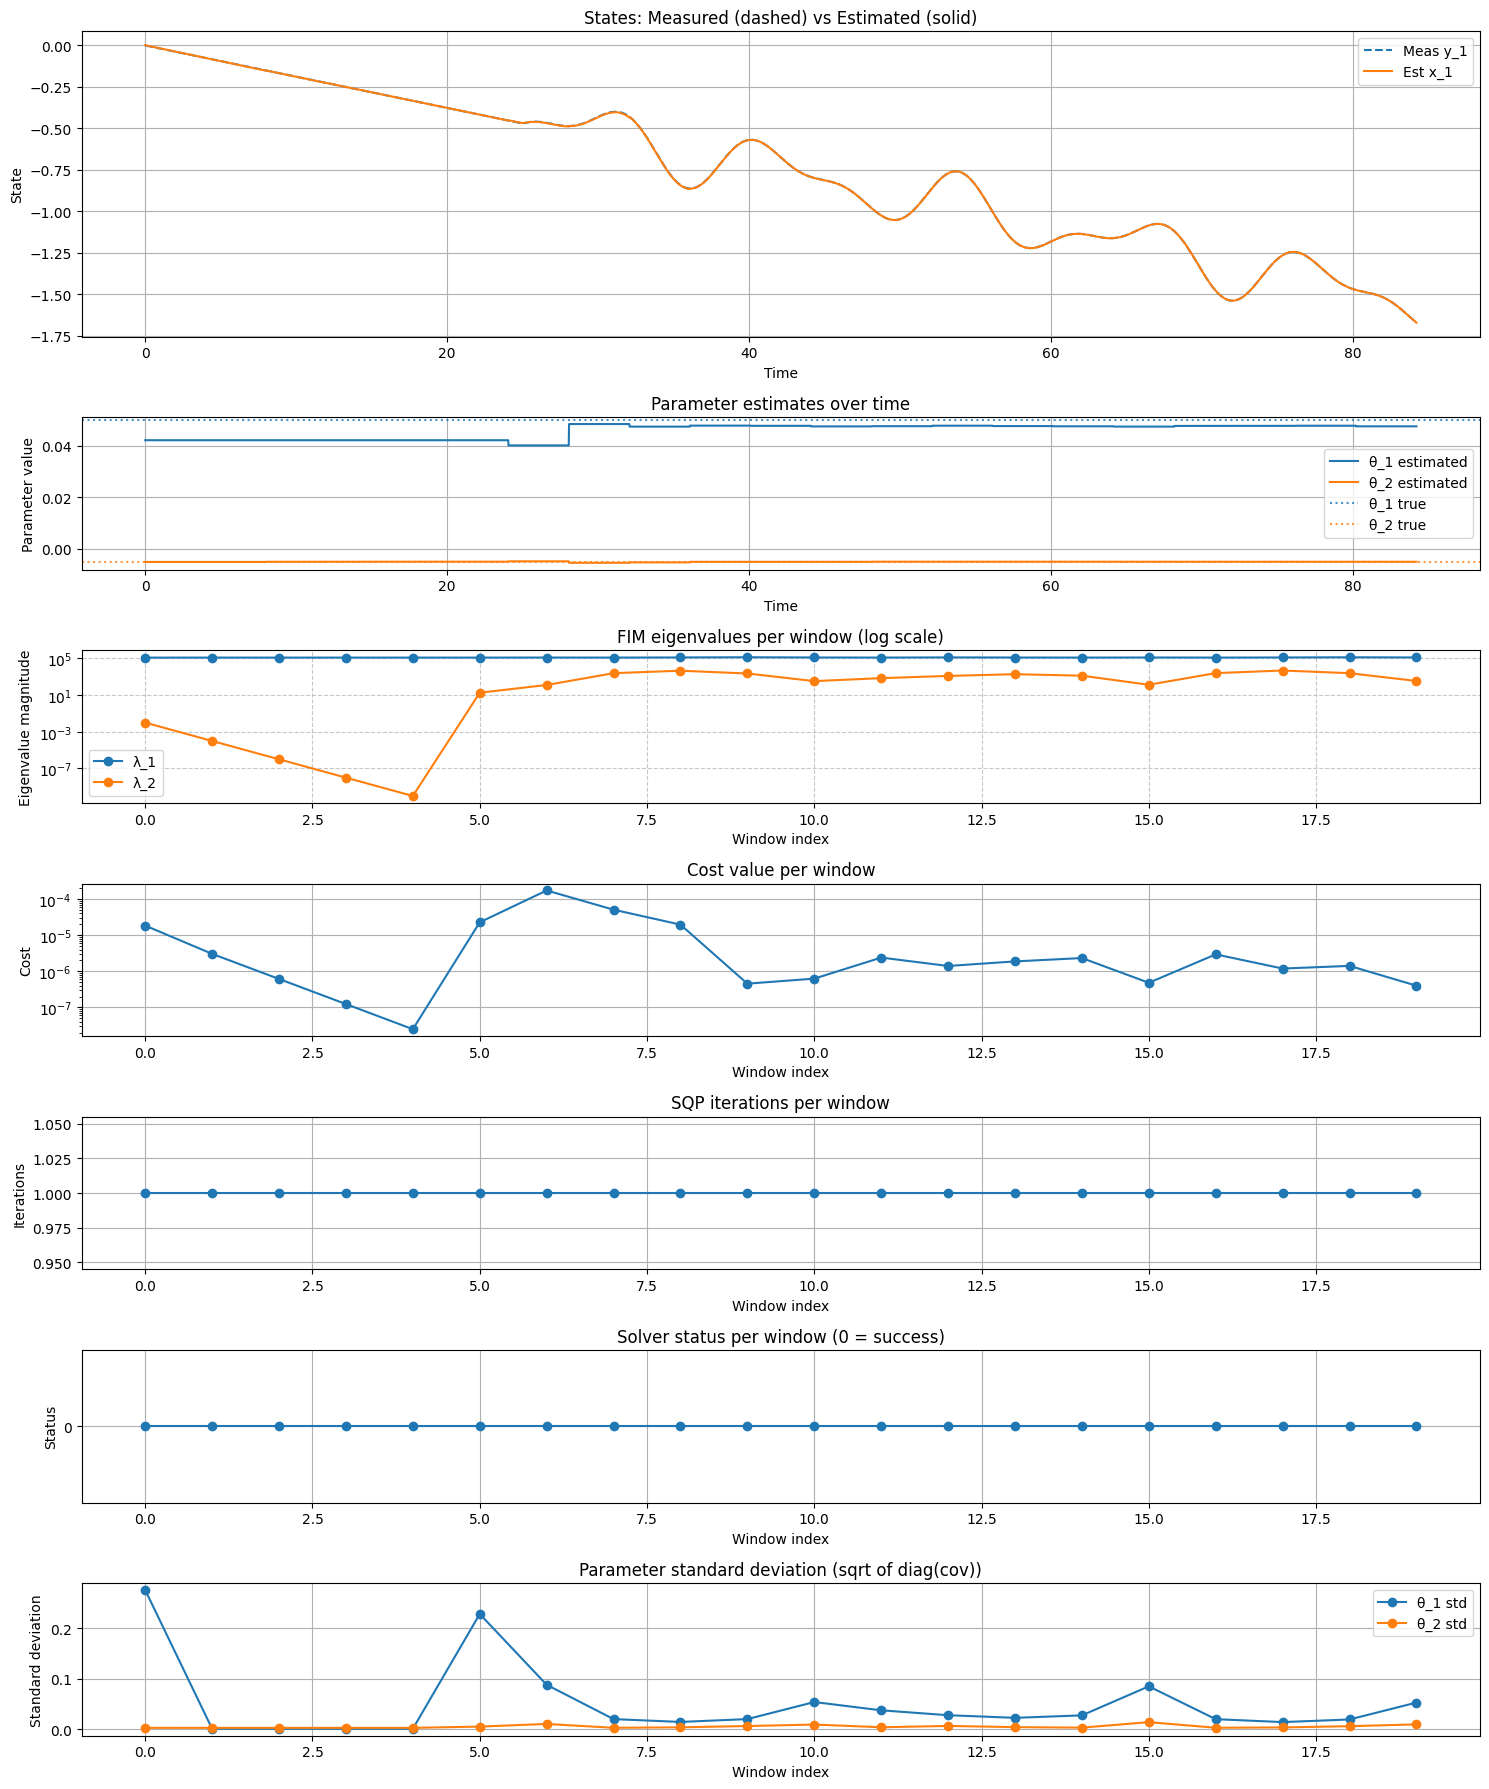

In [11]:
plot_mhe_results(results, overlap=overlap_points,
                 initial_params=None,
                 theta_true=theta_true,   # your true parameter array
                 plot_states=True,
                 plot_params=True,
                 plot_eigvals=True,
                 plot_noise=False,
                 plot_cost=True,
                 plot_iter=True,
                 plot_status=True,
                 figsize=(15, 18))   # slightly larger to accommodate taller first plot

In [14]:
initial_theta = theta_true
t_batch, simU, simY = get_window(1)
unknown_state_length = 0


initial_x0 = np.hstack((simY[0]))
print(initial_x0)
R_inv = np.diag(6*[1])
mhe_model=generator.get_model()
F = mhe_model.compute_fim(simY.shape[0], mhe_params.dt, simU, initial_x0, initial_theta, R_inv)
F
#set_mhe_solver(mhe_model, acados_solver_mhe, simY, simU, initial_x0, initial_theta, mhe_params.dt, N_measurement, unknown_state_length, R_inv)

[ 5.00001520e+03 -1.08042337e+03  1.01599130e+01  1.18124999e-02
 -4.01161542e+01  1.18994929e-01]


array([[ 1.29688597e-01, -3.23480660e-01, -2.59377194e+00,
         1.07826887e+00],
       [-3.23480660e-01,  6.95177071e+02,  6.46961320e+00,
        -2.31725690e+03],
       [-2.59377194e+00,  6.46961320e+00,  5.18754387e+01,
        -2.15653773e+01],
       [ 1.07826887e+00, -2.31725690e+03, -2.15653773e+01,
         7.72418968e+03]])